# Path2Space vs. competing ST prediction methods — Visium / Bassiouni benchmark

Benchmark of Path2Space against 16 published spatial-transcriptomics
expression-prediction methods on the Bassiouni breast-cancer Visium cohort
(training) plus three external cohorts (HEST, HTAN, Martinez).

**Two panels:**

1. **988-HVG benchmark** — 17 published methods (16 competitors plus
   Path2Space; Path2Space and Path2Space-unsmoothed shown separately)
   evaluated on the 988 highly variable genes selected from the Bassiouni
   training cohort. Two normalization regimes: log-counts (`no_cpm`) and
   log-CPM (`cpm`).
2. **Genome-wide benchmark (top-4 competitors)** — for the four most
   competitive methods on the 988-HVG panel (mclSTExp, StFlow, BLEEP,
   EGNv2), the same evaluation extended to all ~13,000 genes the methods
   predict.

Statistical comparison: per-(cohort, validation type) Mann-Whitney U on the
matched per-gene PCC vectors of Path2Space vs. each competitor.

## Upstream training — not done here

The training and prediction for the 16 competing methods was performed by
the authors of the **TRIPLEX** legacy benchmark and is hosted upstream as
part of their Nature Communications artifacts. This component does **not**
redistribute their model weights or training scripts; what is bundled here
are the per-(slide, gene) Pearson correlations between each method's
predicted expression and the measured expression on the QC-passing slides,
aggregated to one PCC per (cohort, gene) by averaging per-patient PCCs.
Path2Space training is in the companion repo,
[`path2space-companion`](https://github.com/eldadshulman/path2space-companion).

## Setup

In [1]:
import sys; sys.path.insert(0, "../lib")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from benchmark import model_order_by_median, mannwhitney_vs_reference, median_pcc_table

## Load the bundled aggregates

In [2]:
bench = pd.read_parquet("../data/bench_988_bassiouni.parquet")
print(f"{len(bench):,} rows  |  models: {bench['model'].nunique()}  |  "
      f"genes: {bench['gene'].nunique()}  |  cohorts: {sorted(bench['cohort'].unique())}")
print(f"validation_types: {sorted(bench['validation_type'].unique())}  |  "
      f"normalizations: {sorted(bench['norm'].unique())}")
bench.head()

148,204 rows  |  models: 19  |  genes: 989  |  cohorts: ['Bassiouni et al.', 'HEST', 'HTAN', 'Martinez et al.']
validation_types: ['cross_val', 'ext_val']  |  normalizations: ['cpm', 'no_cpm']


,norm,model,validation_type,cohort,gene,cor_pearson
0,cpm,BLEEP,cross_val,Bassiouni et al.,A2M,0.129284
1,cpm,BLEEP,cross_val,Bassiouni et al.,ACADVL,0.164303
2,cpm,BLEEP,cross_val,Bassiouni et al.,ACTB,0.111349
3,cpm,BLEEP,cross_val,Bassiouni et al.,ACTG1,0.196125
4,cpm,BLEEP,cross_val,Bassiouni et al.,ACTN1,0.129645


## Median PCC per (model, validation type) — log-counts normalization

In [3]:
log_bench = bench[bench['norm'] == 'no_cpm']
med_log = (log_bench.groupby(['model', 'validation_type'], observed=True)['cor_pearson']
                    .median().unstack('validation_type'))
med_log = med_log.sort_values('ext_val', ascending=False)
med_log.round(3)

validation_type,cross_val,ext_val
model,,
SGN,0.352,0.416
Path2Space,0.518,0.392
mclSTExp,0.509,0.390
Path2Space (unsmoothed),0.461,0.357
EGNv2,0.468,0.340
HisToGene,0.303,0.333
EGGN,0.421,0.330
LocalNet,0.510,0.308
BLEEP,0.465,0.307


## Mann-Whitney U vs Path2Space — per (cohort, validation type)

Two-sided test on the per-gene PCC vectors. The reference is Path2Space;
each competitor is compared to it within the same (cohort, validation_type)
facet so the test is on matched per-gene distributions.

In [4]:
mw = mannwhitney_vs_reference(log_bench, reference="Path2Space",
                              group_cols=("cohort", "validation_type"))
mw = mw[mw.model != "Path2Space (unsmoothed)"]   # focus on competitor comparisons
mw = mw.sort_values(["cohort", "pvalue"]).reset_index(drop=True)
print(f"tests: {len(mw)} (model x cohort x validation_type combinations)")
mw.head(20).round({"median_ref": 3, "median_model": 3, "U": 0, "pvalue": 6})

tests: 68 (model x cohort x validation_type combinations)


,cohort,validation_type,model,n_genes_ref,n_genes_model,median_ref,median_model,U,pvalue
0,Bassiouni et al.,cross_val,BLEEP,989,988,0.518,0.465,687673.0,0.000000
1,Bassiouni et al.,cross_val,DeepPT,989,988,0.518,0.384,886523.0,0.000000
2,Bassiouni et al.,cross_val,DeepSpaCE,989,988,0.518,0.457,739312.0,0.000000
3,Bassiouni et al.,cross_val,EGGN,989,988,0.518,0.421,833712.0,0.000000
4,Bassiouni et al.,cross_val,EGNv2,989,988,0.518,0.468,699034.0,0.000000
5,Bassiouni et al.,cross_val,HisToGene,989,988,0.518,0.303,932117.0,0.000000
6,Bassiouni et al.,cross_val,Hist2ST,989,988,0.518,0.008,977119.0,0.000000
7,Bassiouni et al.,cross_val,HistoSPACE,989,988,0.518,0.458,726130.0,0.000000
8,Bassiouni et al.,cross_val,SGN,989,988,0.518,0.352,913803.0,0.000000
9,Bassiouni et al.,cross_val,STco,989,988,0.518,0.472,675826.0,0.000000


## Figure 3-style box plot — log-counts panel

Per-gene PCC distribution by model; models ordered by their median PCC in
the external validation cohorts (HEST + HTAN + Martinez).

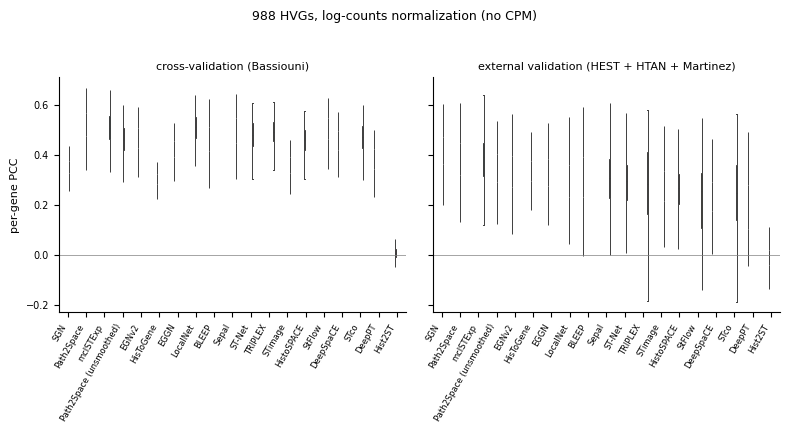

In [5]:
def plot_panel(df, title, figsize=(8, 4.2)):
    order = (df[df['validation_type'] == 'ext_val']
                .groupby('model', observed=True)['cor_pearson'].median()
                .sort_values(ascending=False).index.tolist())
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    for ax, vt, label in zip(axes, ['cross_val', 'ext_val'],
                             ['cross-validation (Bassiouni)', 'external validation (HEST + HTAN + Martinez)']):
        d = df[df['validation_type'] == vt]
        sns.boxplot(data=d, x='model', y='cor_pearson', order=order,
                    hue='model', legend=False, palette='tab20',
                    showfliers=False, width=0.6, linewidth=0.7, ax=ax)
        ax.set_title(label, fontsize=8); ax.set_xlabel('')
        ax.set_ylabel('per-gene PCC' if vt == 'cross_val' else '', fontsize=8)
        ax.tick_params(axis='x', labelsize=6, rotation=60)
        for lab in ax.get_xticklabels(): lab.set_ha('right')
        ax.tick_params(axis='y', labelsize=7)
        ax.axhline(0, color='grey', lw=0.5)
    fig.suptitle(title, fontsize=9, y=1.02)
    sns.despine(); fig.tight_layout(); plt.show()

plot_panel(log_bench, '988 HVGs, log-counts normalization (no CPM)')

## Same, log-CPM normalization

In [6]:
cpm_bench = bench[bench['norm'] == 'cpm']
print(f"cpm subset: {len(cpm_bench):,} rows, {cpm_bench['model'].nunique()} models")
med_cpm = (cpm_bench.groupby(['model', 'validation_type'], observed=True)['cor_pearson']
                    .median().unstack('validation_type'))
med_cpm.sort_values('ext_val', ascending=False).round(3)

cpm subset: 74,102 rows, 19 models


validation_type,cross_val,ext_val
model,,
Path2Space,0.266,0.181
HisToGene,0.159,0.154
Path2Space (unsmoothed),0.221,0.149
TRIPLEX,0.203,0.141
LocalNet,0.223,0.138
mclSTExp,0.228,0.136
SGN,0.005,0.135
Sepal,0.225,0.130
StFlow,0.258,0.125


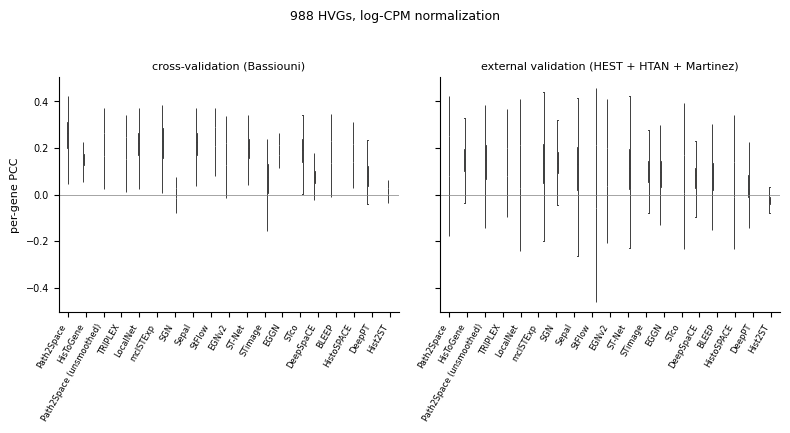

In [7]:
plot_panel(cpm_bench, '988 HVGs, log-CPM normalization')

## Genome-wide benchmark — top-4 competitors

Path2Space against the four highest-ranked competitors on the 988-HVG panel
(mclSTExp, StFlow, BLEEP, EGNv2), evaluated across all ~13,000 genes the
methods predict. Path2Space (unsmoothed) is shown for comparison.

In [8]:
gw = pd.read_parquet("../data/bench_genome_wide_top4.parquet")
print(f"{len(gw):,} rows  |  models: {sorted(gw['model'].unique().tolist())}  |  "
      f"genes: {gw['gene'].nunique()}")
med_gw = (gw.groupby(['model', 'validation_type'], observed=True)['cor_pearson']
             .median().unstack('validation_type'))
med_gw.sort_values('ext_val', ascending=False).round(3)

320,400 rows  |  models: ['BLEEP', 'EGNv2', 'Path2Space', 'Path2Space\n(unsmoothed)', 'StFlow', 'mclSTExp']  |  genes: 13358


validation_type,cross_val,ext_val
model,,
Path2Space,0.207,0.213
EGNv2,0.163,0.185
BLEEP,0.182,0.180
Path2Space\n(unsmoothed),0.182,0.179
StFlow,0.184,0.174
mclSTExp,0.201,0.147


In [9]:
mw_gw = mannwhitney_vs_reference(gw, reference="Path2Space",
                                 group_cols=("cohort", "validation_type"))
mw_gw = mw_gw[mw_gw.model != "Path2Space\n(unsmoothed)"]
mw_gw.sort_values(['cohort','pvalue']).round({"median_ref":3, "median_model":3, "U":0, "pvalue":6}).head(20)

,cohort,validation_type,model,n_genes_ref,n_genes_model,median_ref,median_model,U,pvalue
1,Bassiouni et al.,cross_val,EGNv2,13356,13358,0.207,0.163,106866240.0,0.000000
3,Bassiouni et al.,cross_val,StFlow,13356,13358,0.207,0.184,99340704.0,0.000000
0,Bassiouni et al.,cross_val,BLEEP,13356,13358,0.207,0.182,97671136.0,0.000000
4,Bassiouni et al.,cross_val,mclSTExp,13356,13358,0.207,0.201,91749504.0,0.000054
5,HEST,ext_val,BLEEP,13349,13349,0.231,0.190,104179872.0,0.000000
6,HEST,ext_val,EGNv2,13349,13349,0.231,0.153,117534432.0,0.000000
8,HEST,ext_val,StFlow,13349,13349,0.231,0.166,111288624.0,0.000000
9,HEST,ext_val,mclSTExp,13349,13349,0.231,0.163,114559936.0,0.000000
10,HTAN,ext_val,BLEEP,13336,13336,0.203,0.162,106736592.0,0.000000
14,HTAN,ext_val,mclSTExp,13336,13336,0.203,0.167,105209808.0,0.000000


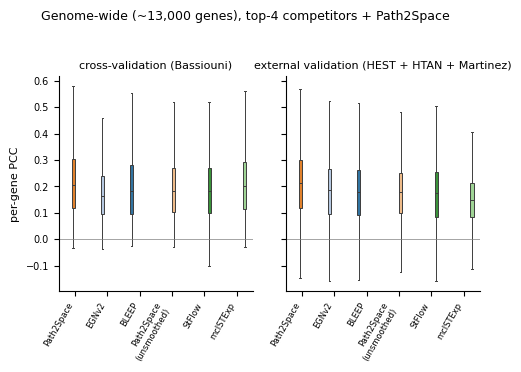

In [10]:
plot_panel(gw, 'Genome-wide (~13,000 genes), top-4 competitors + Path2Space',
           figsize=(5, 3.6))

## Save summary tables

In [11]:
med_log.to_pickle("../data/median_pcc_988_no_cpm.pkl")
med_cpm.to_pickle("../data/median_pcc_988_cpm.pkl")
med_gw.to_pickle("../data/median_pcc_genome_wide.pkl")
mw.to_pickle("../data/mannwhitney_988_no_cpm.pkl")
mw_gw.to_pickle("../data/mannwhitney_genome_wide.pkl")
print("wrote 5 summary pickles into ../data/")

wrote 5 summary pickles into ../data/


## Takeaway

Across both panels of the Bassiouni Visium benchmark — 988 HVGs across 17
methods and the genome-wide top-4 subset — Path2Space's per-gene PCC
distribution sits at or near the top of the field in both the held-out
cross-validation cohort (Bassiouni patients not used for training) and the
three external cohorts. The Mann-Whitney U tests against each competitor
are reported per (cohort, validation type) so a reader can read off the
magnitude and direction of every pairwise comparison.

**Note on SGN.** Under `no_cpm` normalization, SGN ranks first by external-
validation median (0.42 vs Path2Space 0.39). Under `cpm` normalization,
however, SGN's median collapses to ≈ 0 — a pattern inconsistent with every
other method in the comparison and suggesting a normalization/training
artifact specific to SGN's `no_cpm` output. The published Figure 3 panel
excludes SGN for this reason. This notebook keeps SGN visible to surface
the inconsistency rather than hide it; treat the SGN bar as suspect.